<img src="./logo_UNSAM.png" align="right" width="150" /> 

# Trabajo Semanal Nº7

#### Nicolás Galván

## Introducción

El electrocardiograma (ECG) es una de las señales biomédicas más utilizadas para el diagnóstico y monitoreo de la actividad cardíaca. Su análisis permite identificar alteraciones en el ritmo cardíaco, detectar arritmias y evaluar distintas patologías cardiovasculares a partir de la observación de las ondas P, complejo QRS y onda T que componen cada ciclo cardíaco.

Sin embargo, durante la adquisición de la señal es frecuente que aparezcan diversas fuentes de contaminación que dificultan la interpretación clínica y el procesamiento automático del registro. Entre las principales interferencias presentes en un ECG registrado durante una prueba de esfuerzo se encuentran el movimiento de la línea de base producido por la respiración y los desplazamientos del paciente, el ruido muscular (EMG) y el ruido de alta frecuencia asociado al movimiento de los electrodos y a perturbaciones del sistema de medición.

El objetivo de este trabajo práctico consiste en diseñar e implementar filtros digitales capaces de atenuar dichas interferencias preservando la información fisiológicamente relevante del ECG. Para ello se utilizará un registro muestreado a 1 kHz contenido en el archivo `ecg.mat`, junto con patrones representativos de latidos normales y ventriculares que servirán como referencia para evaluar cualitativamente el resultado del filtrado.

Como punto de partida, se establecerá una plantilla de diseño a partir del ancho de banda útil del ECG obtenido en trabajos previos. Esta plantilla definirá las bandas de paso y rechazo necesarias para conservar la morfología característica de los latidos mientras se elimina el movimiento de la línea de base y el contenido espectral asociado al ruido de alta frecuencia.

Posteriormente se diseñarán y compararán diferentes familias de filtros digitales. En particular, se analizarán filtros IIR obtenidos mediante aproximaciones de Butterworth, Chebyshev y Cauer, y filtros FIR diseñados mediante métodos de ventanas y aproximación directa de la respuesta en frecuencia. Para cada alternativa se verificará el cumplimiento de las especificaciones mediante el estudio de la respuesta en frecuencia, fase y retardo de grupo.

Finalmente, se evaluará el desempeño de los filtros sobre el registro de ECG, verificando tanto la capacidad de atenuar las componentes interferentes como la preservación de las características morfológicas de la señal en regiones libres de ruido. La comparación permitirá discutir las ventajas y limitaciones de cada técnica de diseño en términos de selectividad, distorsión de fase, complejidad computacional y calidad del filtrado obtenido.

# Ejercicio Nº1

# a)

In [20]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
import scipy.io as sio

In [21]:
# ============================================================
# CARGA DE DATOS
# ============================================================
mat_struct = sio.loadmat('ECG_TP4.mat')
ecg_one_lead = mat_struct['ecg_lead'].flatten()
fs = 1000
cant_muestras = ecg_one_lead.shape[0]

In [22]:
# ============================================================
# PLANTILLA DEL FILTRO
# ============================================================
gpass = 1
gstop = 40

# Frecuencias de la plantilla (para firwin2 y para los plots)
ws1, wp1 = 0.69, 0.85
wp2, ws2 = 35, 35.5

ws1_plot = 0.1
wp1_plot = 1.17
wp2_plot = 34.8
ws2_plot = 45

frecs = np.array([0, ws1, wp1, wp2, ws2, fs/2])
gains = np.array([-gstop, -gstop, -gpass, -gpass, -gstop, -gstop])
gains = 10**(gains / 20)
gains[5] = 0
gains[0] = 0

PISO_DB = -125
TECHO_DB = 10
# ============================================================
# PARÁMETROS DE AJUSTE POR FILTRO FIR
# ============================================================

# --- Cuadrados Mínimos (firls) ---
ws1_ls, wp1_ls = 0.73, 0.85       # transición inferior [Hz]
wp2_ls, ws2_ls = 35.0, 35.5      # transición superior [Hz]

## b)

### Determinación de la plantilla de diseño

Para definir la plantilla de diseño de los filtros digitales se partió de las especificaciones teóricas habituales para señales ECG. En una primera aproximación se consideraron las siguientes frecuencias características:

- Banda de rechazo inferior: $ f_{s1} = 0.1 \, \text{Hz} $
- Banda de paso inferior: $ f_{p1} = 1 \, \text{Hz} $
- Banda de paso superior: $ f_{p2} = 35 \, \text{Hz} $
- Banda de rechazo superior: $ f_{s2} = 45 \, \text{Hz} $

Estos valores permiten eliminar el desplazamiento de la línea de base (baseline wander) y atenuar componentes de ruido muscular y de movimiento presentes en altas frecuencias.

Sin embargo, al analizar el espectro de la señal ECG registrada, se observó que parte de la información útil asociada a los complejos cardíacos se encontraba próxima a los límites inicialmente establecidos. Como consecuencia, el filtro comenzaba a afectar componentes relevantes de la señal, produciendo una atenuación no deseada de algunas características morfológicas del ECG.

Por este motivo, se decidió realizar un ajuste de la plantilla, adoptando finalmente los siguientes valores:

- Banda de rechazo inferior: $ f_{s1} = 0.1 \, \text{Hz} $
- Banda de paso inferior: $ f_{p1} = 1.17 \, \text{Hz} $
- Banda de paso superior: $ f_{p2} = 34.8 \, \text{Hz} $
- Banda de rechazo superior: $ f_{s2} = 45 \, \text{Hz} $

La modificación consistió en relajar ligeramente las transiciones del filtro para evitar que la respuesta en frecuencia afectara componentes pertenecientes a la señal ECG. De esta manera se otorgó mayor libertad al diseño, permitiendo preservar mejor la información cardíaca mientras se mantiene una adecuada atenuación de las perturbaciones presentes fuera de la banda de interés.

Los valores finales fueron obtenidos mediante un proceso iterativo de análisis espectral y observación de la señal filtrada, verificando que el resultado presentara una línea isoeléctrica cercana a cero y trazos más suaves, sin degradar significativamente la forma característica de los latidos.

## c)

Defion mis funciones auxiliares

In [23]:
def agregar_plantilla(ax):
    kw_f = dict(color='green', alpha=0.15)
    kw_l = dict(color='k', ls='--', lw=1, alpha=0.7)
    ax.fill_between([0, ws1_plot],      -gstop, TECHO_DB, label='Plantilla', **kw_f)
    ax.plot(        [0, ws1_plot],      [-gstop, -gstop],                    **kw_l)
    ax.fill_between([wp1_plot, wp2_plot], PISO_DB, -gpass,                   **kw_f)
    ax.plot(        [wp1_plot, wp2_plot], [-gpass, -gpass],                   **kw_l)
    ax.fill_between([wp1_plot, wp2_plot], 3, TECHO_DB,                        **kw_f)
    ax.plot(        [wp1_plot, wp2_plot], [3, 3],                             **kw_l)
    ax.fill_between([ws2_plot, fs/2],   -gstop, TECHO_DB,                    **kw_f)
    ax.plot(        [ws2_plot, fs/2],   [-gstop, -gstop],                    **kw_l)
    for vx in [ws1_plot, wp1_plot, wp2_plot, ws2_plot]:
        ax.axvline(vx, color='k', ls=':', alpha=0.5)


def get_mag_fase_gd(w, h):
    mod_db = 20 * np.log10(np.maximum(np.abs(h), 10**(PISO_DB / 20)))
    fase   = np.unwrap(np.angle(h))
    w_rad  = w / (fs / 2) * np.pi
    gd     = -np.diff(fase) / np.diff(w_rad)
    return mod_db, fase, gd


def plot_plantilla_completa_doble(w1, h1, label1,
                                  w2, h2, label2,
                                  titulo):
    def _mag(h):
        return 20 * np.log10(np.maximum(np.abs(h), 10**(PISO_DB / 20)))
    fig, ax = plt.subplots(figsize=(12, 5), tight_layout=True)
    ax.set_title(titulo)
    ax.plot(w1, _mag(h1), 'r--', lw=1.8, label=label1)
    ax.plot(w2, _mag(h2), 'g-.', lw=1.8, label=label2)
    agregar_plantilla(ax)
    ax.set_ylabel('Amplitud [dB]')
    ax.set_xlabel('Frecuencia [Hz]')
    ax.set_xlim(0, fs / 2)
    ax.set_ylim([PISO_DB, TECHO_DB])
    ax.grid(True, which='both', linestyle='-', alpha=0.4)
    ax.legend(loc='lower right')
    plt.show()


def plot_plantilla_completa_triple(w1, h1, label1,
                                   w2, h2, label2,
                                   w3, h3, label3,
                                   titulo):
    def _mag(h):
        return 20 * np.log10(np.maximum(np.abs(h), 10**(PISO_DB / 20)))
    fig, ax = plt.subplots(figsize=(12, 5), tight_layout=True)
    ax.set_title(titulo)
    ax.plot(w1, _mag(h1), 'b',   lw=1.8, label=label1)
    ax.plot(w2, _mag(h2), 'r--', lw=1.8, label=label2)
    ax.plot(w3, _mag(h3), 'g-.', lw=1.8, label=label3)
    agregar_plantilla(ax)
    ax.set_ylabel('Amplitud [dB]')
    ax.set_xlabel('Frecuencia [Hz]')
    ax.set_xlim(0, fs / 2)
    ax.set_ylim([PISO_DB, TECHO_DB])
    ax.grid(True, which='both', linestyle='-', alpha=0.4)
    ax.legend(loc='lower right')
    plt.show()


# ============================================================
# PLOT ECG REGIONES — SUBPLOTS SEPARADOS POR SEÑAL
# ============================================================

def plot_ecg_regiones_doble(ecg_orig,
                             ecg_filt1, nombre1,
                             ecg_filt2, nombre2,
                             demora1=0, demora2=0):
    regiones = [
        ('sin ruido', [4000,  5500 ]),
        ('sin ruido', [10000, 11000]),
        ('con ruido', np.array([5,  5.2 ]) * 60 * fs),
        ('con ruido', np.array([12, 12.4]) * 60 * fs),
        ('con ruido', np.array([15, 15.2]) * 60 * fs),
    ]
    filtros = [(ecg_filt1, nombre1, demora1, 'tab:red'),
               (ecg_filt2, nombre2, demora2, 'tab:green')]

    for tipo, ii in regiones:
        zr = np.arange(np.max([0, ii[0]]),
                       np.min([cant_muestras, ii[1]]),
                       dtype='uint')
        if len(zr) == 0:
            continue

        fig, axes = plt.subplots(
            1, len(filtros),
            figsize=(5 * len(filtros), 3),
            sharey=True,
            tight_layout=True
        )
        fig.suptitle(
            f'FIR — {tipo} | muestras {ii[0]:.0f}–{ii[1]:.0f}',
            fontsize=11
        )

        for ax, (ecg_f, nombre, demora, color) in zip(axes, filtros):
            idx_f = np.clip(zr.astype(int) + demora, 0, len(ecg_f) - 1)
            ax.plot(zr, ecg_orig[zr], 'k',         lw=1.8, label='ECG original', alpha=0.6)
            ax.plot(zr, ecg_f[idx_f], color=color,  lw=1.2, label=nombre)
            ax.set_title(nombre, fontsize=10)
            ax.set_xlabel('Muestras (#)')
            ax.set_yticks(())
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

        axes[0].set_ylabel('Adimensional')
        plt.show()


def plot_ecg_regiones_triple(ecg_orig,
                              ecg_filt1, nombre1,
                              ecg_filt2, nombre2,
                              ecg_filt3, nombre3,
                              demora1=0, demora2=0, demora3=0):
    regiones = [
        ('sin ruido', [4000,  5500 ]),
        ('sin ruido', [10000, 11000]),
        ('con ruido', np.array([5,  5.2 ]) * 60 * fs),
        ('con ruido', np.array([12, 12.4]) * 60 * fs),
        ('con ruido', np.array([15, 15.2]) * 60 * fs),
    ]
    filtros = [(ecg_filt1, nombre1, demora1, 'tab:blue'),
               (ecg_filt2, nombre2, demora2, 'tab:red'),
               (ecg_filt3, nombre3, demora3, 'tab:green')]

    for tipo, ii in regiones:
        zr = np.arange(np.max([0, ii[0]]),
                       np.min([cant_muestras, ii[1]]),
                       dtype='uint')
        if len(zr) == 0:
            continue

        fig, axes = plt.subplots(
            1, len(filtros),
            figsize=(5 * len(filtros), 3),
            sharey=True,
            tight_layout=True
        )
        fig.suptitle(
            f'IIR — {tipo} | muestras {ii[0]:.0f}–{ii[1]:.0f}',
            fontsize=11
        )

        for ax, (ecg_f, nombre, demora, color) in zip(axes, filtros):
            idx_f = np.clip(zr.astype(int) + demora, 0, len(ecg_f) - 1)
            ax.plot(zr, ecg_orig[zr], 'k',         lw=1.8, label='ECG original', alpha=0.6)
            ax.plot(zr, ecg_f[idx_f], color=color,  lw=1.2, label=nombre)
            ax.set_title(nombre, fontsize=10)
            ax.set_xlabel('Muestras (#)')
            ax.set_yticks(())
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

        axes[0].set_ylabel('Adimensional')
        plt.show()

Defino mi IIR de Butterworth.

In [24]:
# ============================================================
# IIR — BUTTERWORTH
# ============================================================
mi_sos_butt = signal.iirdesign(
    wp=[wp1_plot, wp2_plot], ws=[ws1_plot, ws2_plot],
    gpass=gpass, gstop=gstop,
    analog=False, ftype='butter', output='sos', fs=fs
)
ECG_butt = signal.sosfilt(mi_sos_butt, ecg_one_lead)
w_b, h_b   = signal.sosfreqz(mi_sos_butt, worN=2048, fs=fs)
mod_b, fas_b, gd_b = get_mag_fase_gd(w_b, h_b)


Defino mi IIR de Cauer.

In [25]:
# ============================================================
# IIR — CAUER
# ============================================================
mi_sos_cauer = signal.iirdesign(
    wp=[wp1_plot, wp2_plot], ws=[ws1_plot, ws2_plot],
    gpass=gpass, gstop=gstop,
    analog=False, ftype='cauer', output='sos', fs=fs
)
ECG_cauer = signal.sosfilt(mi_sos_cauer, ecg_one_lead)
w_c, h_c   = signal.sosfreqz(mi_sos_cauer, worN=2048, fs=fs)
mod_c, fas_c, gd_c = get_mag_fase_gd(w_c, h_c)


Defino mi IIR de Chebyshev II.

In [26]:
# ============================================================
# IIR — CHEBYSHEV II
# ============================================================
mi_sos_cheby2 = signal.iirdesign(
    wp=[wp1_plot, wp2_plot], ws=[ws1_plot, ws2_plot],
    gpass=gpass, gstop=gstop,
    analog=False, ftype='cheby2', output='sos', fs=fs
)
ECG_cheby2 = signal.sosfilt(mi_sos_cheby2, ecg_one_lead)
w_ch, h_ch = signal.sosfreqz(mi_sos_cheby2, worN=2048, fs=fs)
mod_ch, fas_ch, gd_ch = get_mag_fase_gd(w_ch, h_ch)


Grafico mis IIR.

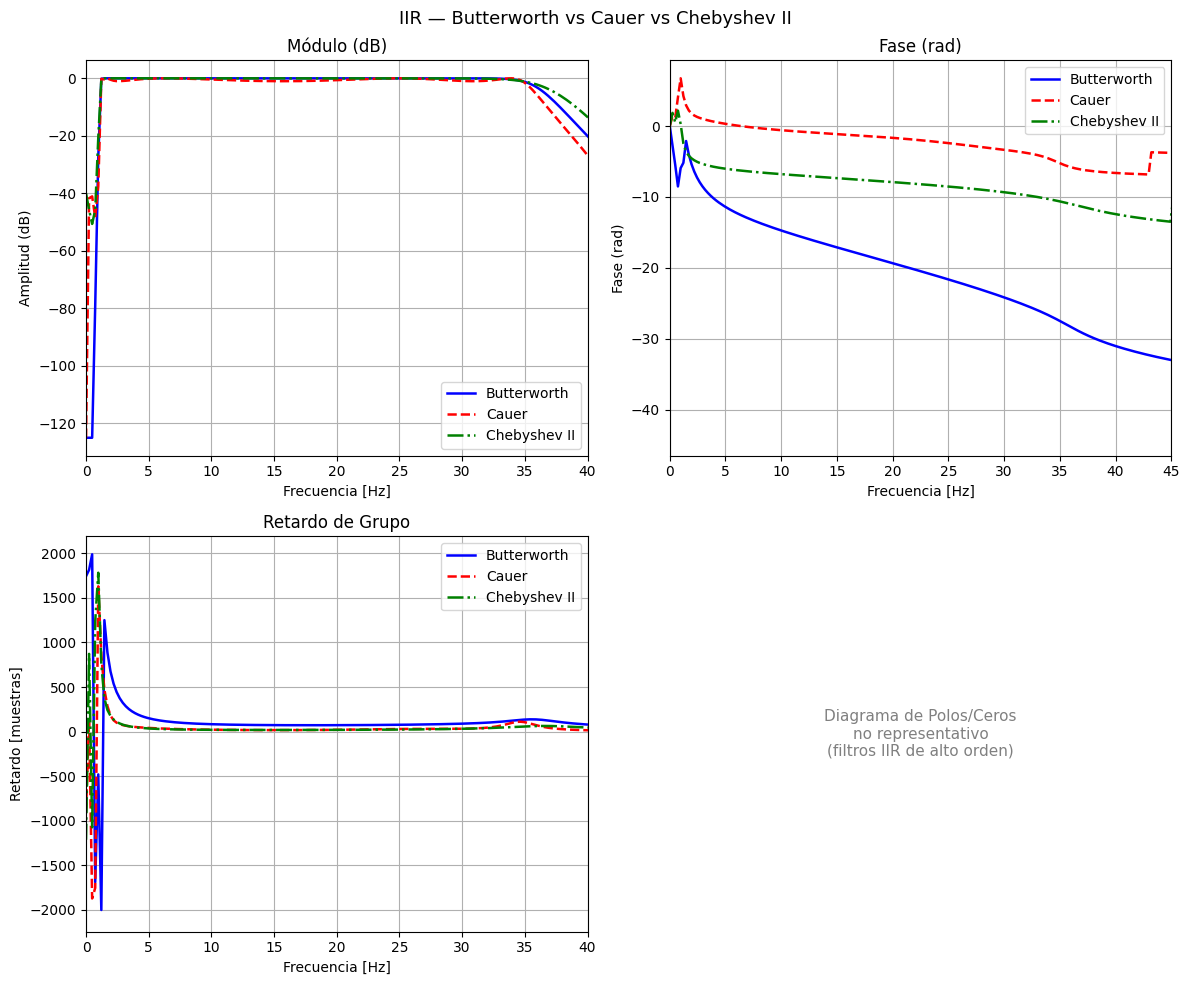

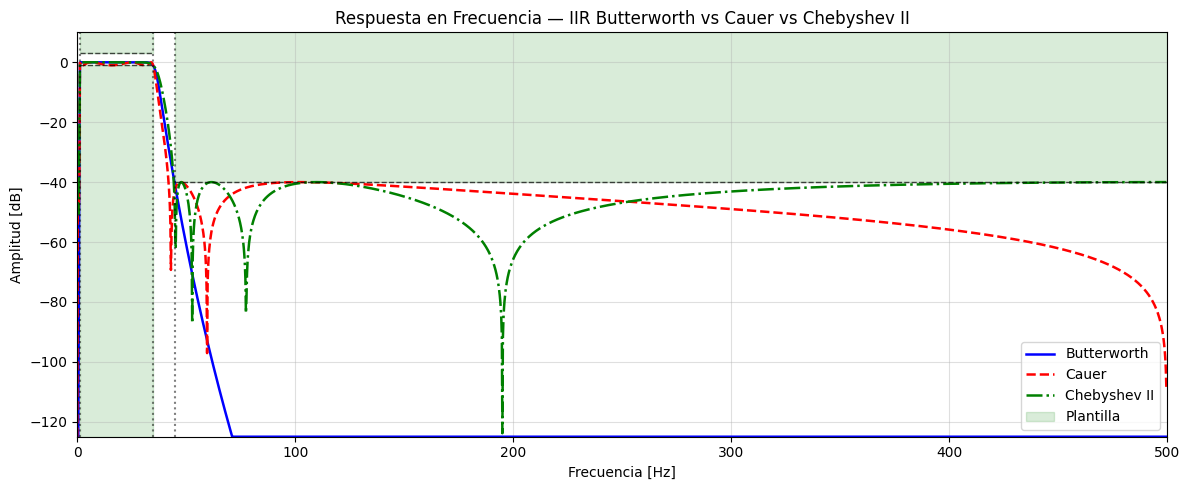

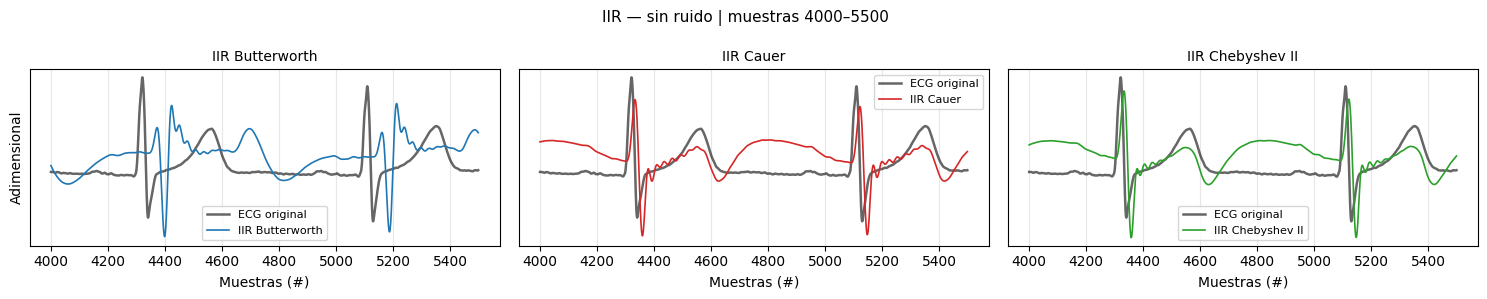

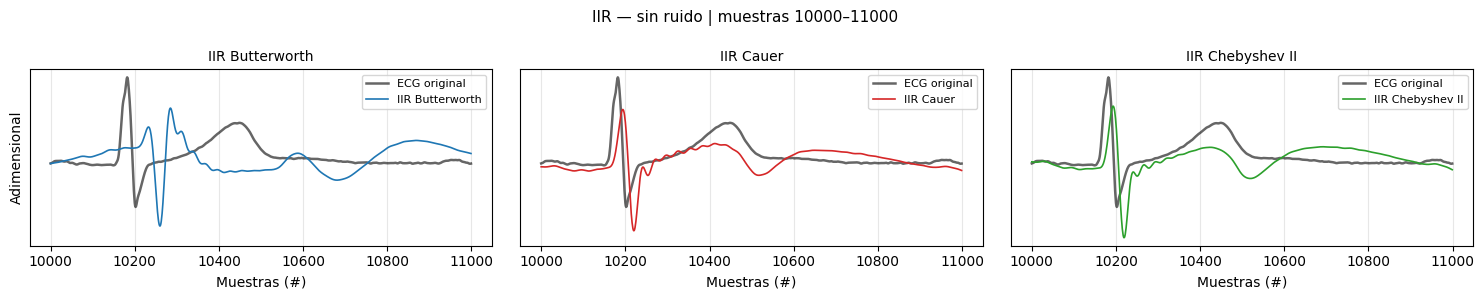

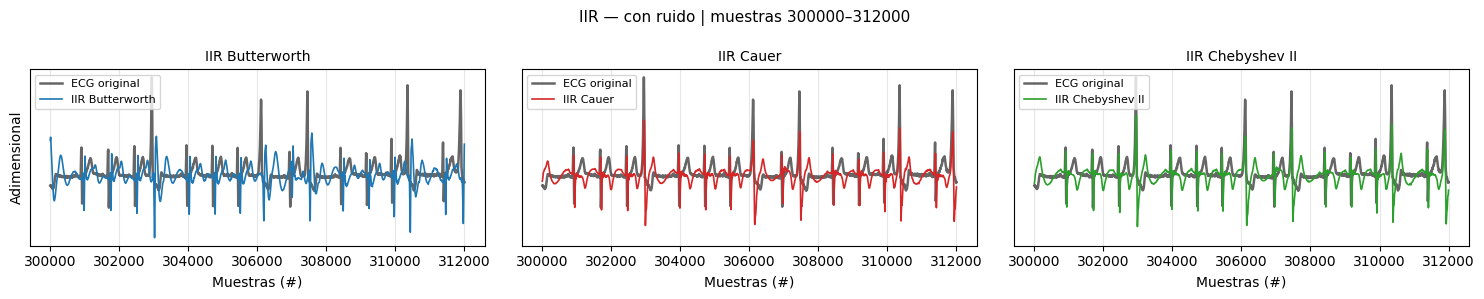

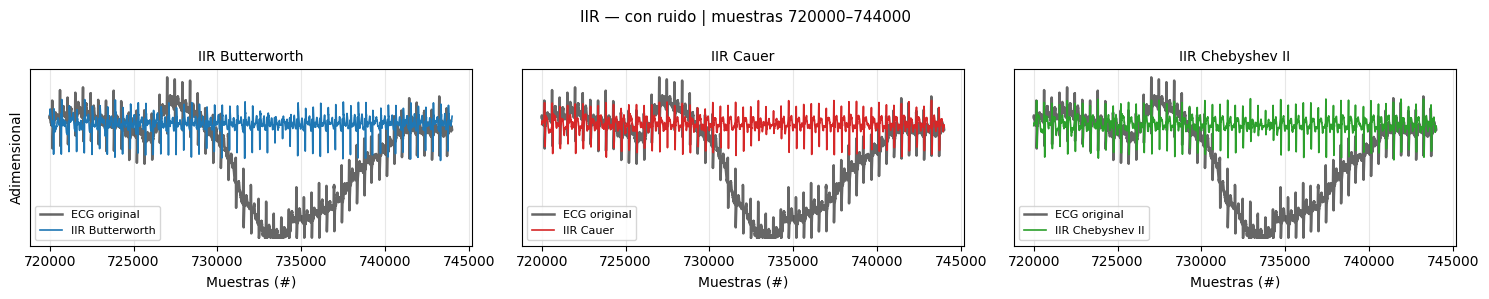

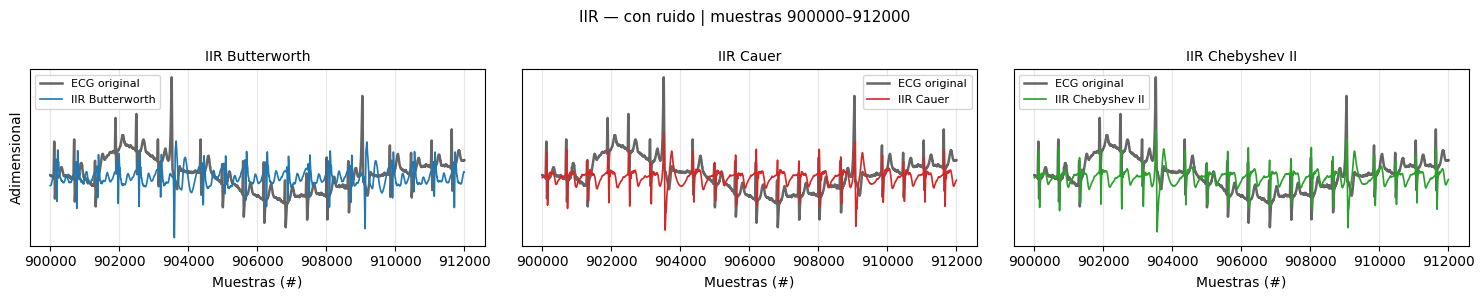

In [27]:
# ============================================================
# IIR — 4 paneles comparativos (Butterworth vs Cauer vs Cheby2)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10), tight_layout=True)
fig.suptitle('IIR — Butterworth vs Cauer vs Chebyshev II', fontsize=13)

axes[0, 0].plot(w_b, mod_b, 'b',   lw=1.8, label='Butterworth')
axes[0, 0].plot(w_c, mod_c, 'r--', lw=1.8, label='Cauer')
axes[0, 0].plot(w_ch, mod_ch, 'g-.',lw=1.8, label='Chebyshev II')
axes[0, 0].set_title('Módulo (dB)')
axes[0, 0].set_ylabel('Amplitud (dB)')
axes[0, 0].set_xlabel('Frecuencia [Hz]')
axes[0, 0].set_xlim(0, 40)
axes[0, 0].legend()
axes[0, 0].grid()

axes[0, 1].plot(w_b, fas_b, 'b',   lw=1.8, label='Butterworth')
axes[0, 1].plot(w_c, fas_c, 'r--', lw=1.8, label='Cauer')
axes[0, 1].plot(w_ch, fas_ch, 'g-.',lw=1.8, label='Chebyshev II')
axes[0, 1].set_title('Fase (rad)')
axes[0, 1].set_ylabel('Fase (rad)')
axes[0, 1].set_xlabel('Frecuencia [Hz]')
axes[0, 1].set_xlim(0, 45)
axes[0, 1].legend()
axes[0, 1].grid()

axes[1, 0].plot(w_b[:-1], gd_b, 'b',    lw=1.8, label='Butterworth')
axes[1, 0].plot(w_c[:-1], gd_c, 'r--',  lw=1.8, label='Cauer')
axes[1, 0].plot(w_ch[:-1], gd_ch, 'g-.', lw=1.8, label='Chebyshev II')
axes[1, 0].set_title('Retardo de Grupo')
axes[1, 0].set_ylabel('Retardo [muestras]')
axes[1, 0].set_xlabel('Frecuencia [Hz]')
axes[1, 0].set_xlim(0, 40)
axes[1, 0].legend()
axes[1, 0].grid()

axes[1, 1].axis('off')
axes[1, 1].text(0.5, 0.5,
                'Diagrama de Polos/Ceros\nno representativo\n(filtros IIR de alto orden)',
                ha='center', va='center', fontsize=11, color='gray',
                transform=axes[1, 1].transAxes)
plt.show()

# --- Plantilla IIR ---
plot_plantilla_completa_triple(
    w_b, h_b, 'Butterworth',
    w_c, h_c, 'Cauer',
    w_ch, h_ch, 'Chebyshev II',
    'Respuesta en Frecuencia — IIR Butterworth vs Cauer vs Chebyshev II'
)

# --- ECG regiones IIR ---
plot_ecg_regiones_triple(
    ecg_one_lead,
    ECG_butt,   'IIR Butterworth',
    ECG_cauer,  'IIR Cauer',
    ECG_cheby2, 'IIR Chebyshev II'
)

Defino mi FIR de Ventana Boxcar.

In [28]:
# ============================================================
# FIR — VENTANA BOXCAR
# ============================================================
w_dense_x = np.unique(np.concatenate([
    np.logspace(-2, 0, 500),
    np.linspace( 1.26, 35, 200),
    np.linspace( 0.5,  2,  800),       # resolución extra ~1 Hz
    np.linspace( 5,    7,  800),       # resolución extra ~6 Hz
    np.linspace( 34, 38, 800),       # resolución extra zona de corte
    np.logspace( 1.55, 1.65, 200),
    np.linspace(46, fs//2, 500),
]))

fir_boxcar = signal.firwin2(numtaps=1999, freq=frecs, gain=gains,
                             fs=fs, window='boxcar')
ECG_boxcar = signal.lfilter(b=fir_boxcar, a=1, x=ecg_one_lead)
w_x, h_x   = signal.freqz(b=fir_boxcar, worN=w_dense_x, fs=fs)
mod_x, fas_x, gd_x = get_mag_fase_gd(w_x, h_x)

Defino mi FIR de Cuadrados Mínimos.

In [29]:
# ============================================================
# FIR — CUADRADOS MÍNIMOS (firls)
# ============================================================
cant_coef = 2001
demora_fir = cant_coef - 1

w_dense_ls = np.unique(np.concatenate([
    np.logspace(-2, 0, 500),
    np.linspace( 1.26, 35, 400),
    np.linspace( 0.5,  2,  800),       # resolución extra ~1 Hz
    np.linspace( 5,    7,  800),       # resolución extra ~6 Hz
    np.linspace( 34, 38, 800),       # resolución extra zona de corte
    np.logspace( 1.55, 1.65, 400),
    np.linspace(46, fs//2, 500),
]))

frecs_ls = np.array([0,      ws1_ls,
                     wp1_ls, wp2_ls,
                     ws2_ls, fs/2  ]) / (fs / 2)
gains_ls = np.array([0, 0,
                     1, 1,
                     0, 0], dtype=float)

fir_ls = signal.firls(numtaps=cant_coef,
                      bands=frecs_ls,
                      desired=gains_ls)
ECG_ls = signal.lfilter(b=fir_ls, a=1, x=ecg_one_lead)
w_ls, h_ls = signal.freqz(b=fir_ls, worN=w_dense_ls, fs=fs)
mod_ls, fas_ls, gd_ls = get_mag_fase_gd(w_ls, h_ls)

Grafico mis FIR.

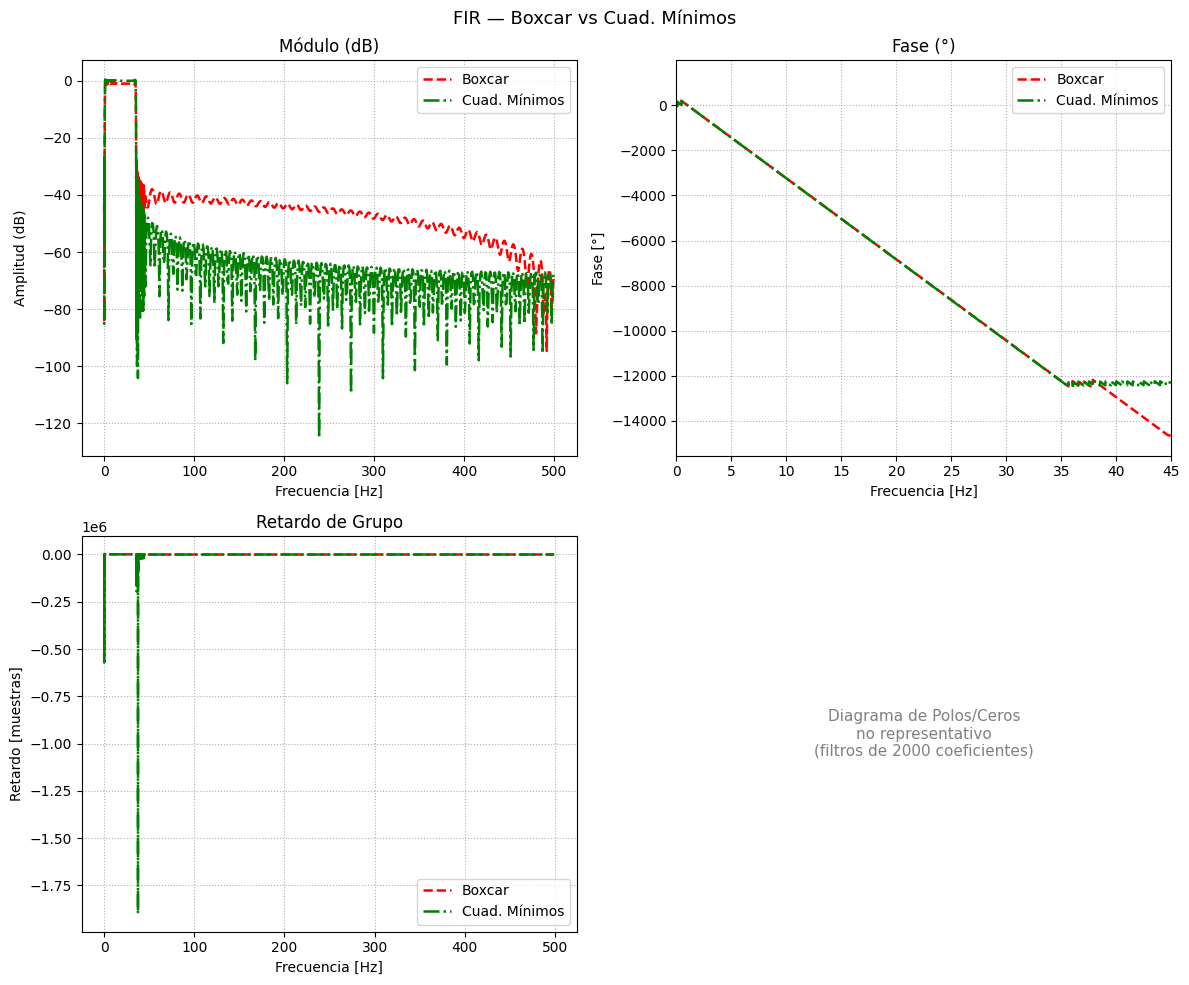

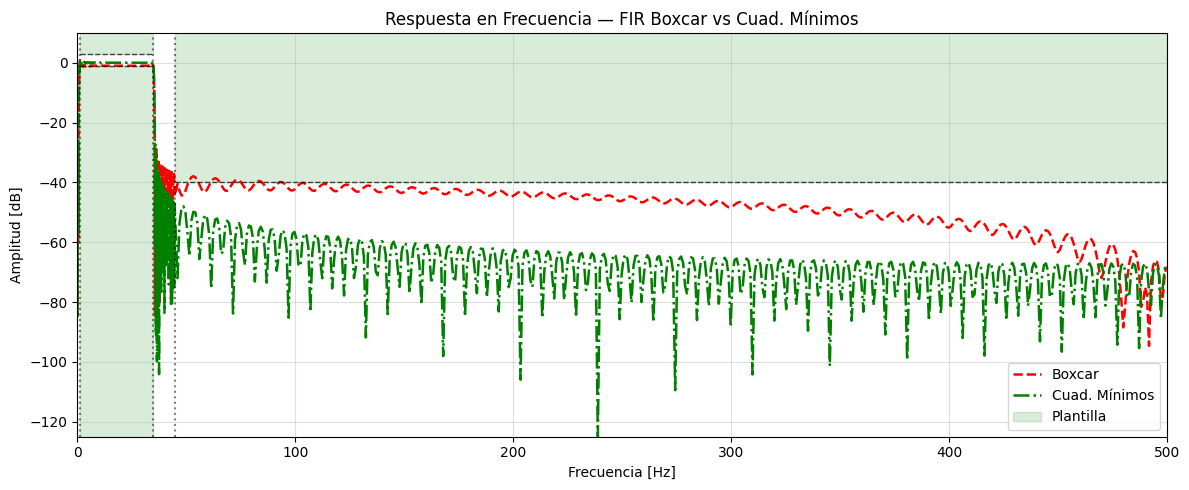

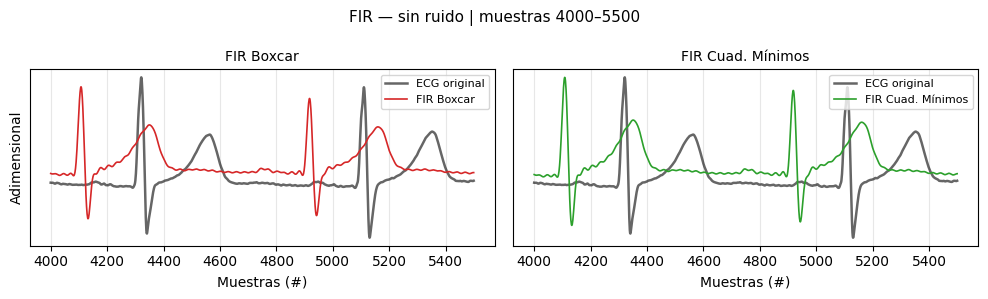

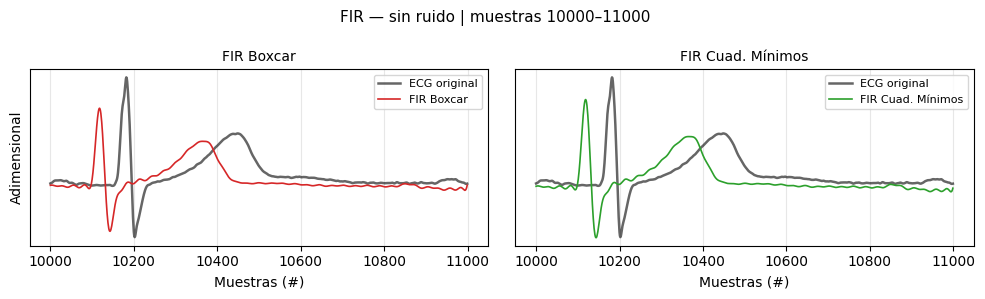

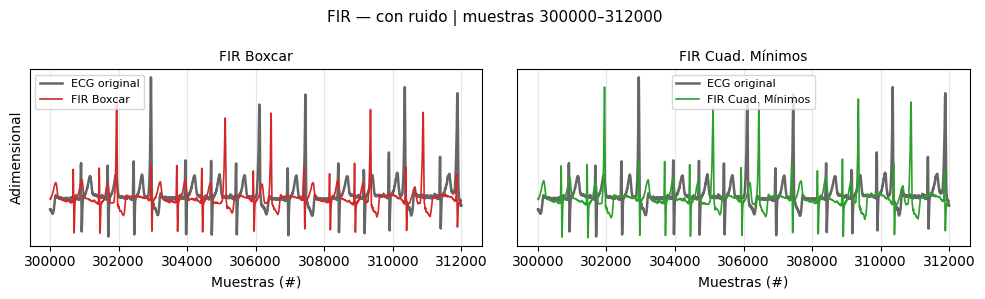

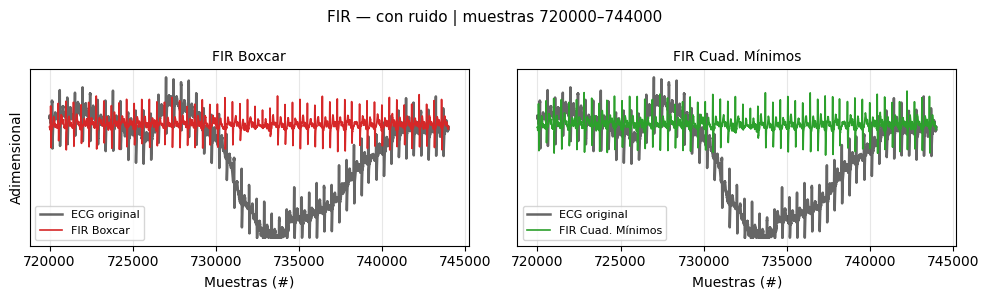

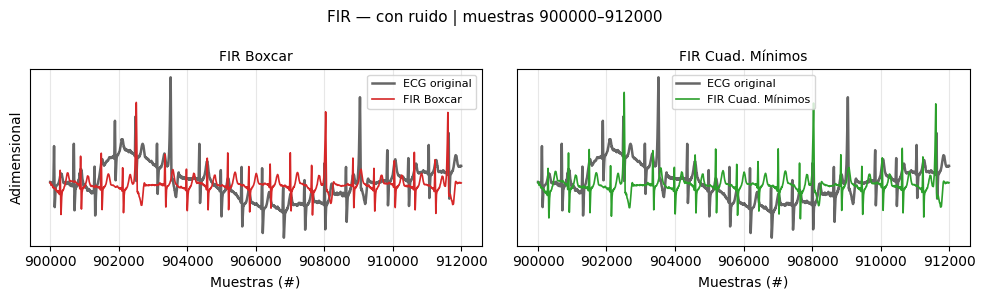

In [30]:
# ============================================================
# FIR — 2 paneles comparativos (Boxcar vs Cuad. Mínimos)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10), tight_layout=True)
fig.suptitle('FIR — Boxcar vs Cuad. Mínimos', fontsize=13)

axes[0, 0].plot(w_x,  mod_x,  'r--', lw=1.8, label='Boxcar')
axes[0, 0].plot(w_ls, mod_ls, 'g-.', lw=1.8, label='Cuad. Mínimos')
axes[0, 0].set_title('Módulo (dB)')
axes[0, 0].set_ylabel('Amplitud (dB)')
axes[0, 0].set_xlabel('Frecuencia [Hz]')
axes[0, 0].grid(True, which='both', ls=':')
axes[0, 0].legend()

axes[0, 1].plot(w_x,  np.degrees(fas_x),  'r--', lw=1.8, label='Boxcar')
axes[0, 1].plot(w_ls, np.degrees(fas_ls), 'g-.', lw=1.8, label='Cuad. Mínimos')
axes[0, 1].set_title('Fase (°)')
axes[0, 1].set_ylabel('Fase [°]')
axes[0, 1].set_xlabel('Frecuencia [Hz]')
axes[0, 1].set_xlim(0, 45)
axes[0, 1].grid(True, which='both', ls=':')
axes[0, 1].legend()

axes[1, 0].plot(w_x[:-1],  gd_x,  'r--', lw=1.8, label='Boxcar')
axes[1, 0].plot(w_ls[:-1], gd_ls, 'g-.', lw=1.8, label='Cuad. Mínimos')
axes[1, 0].set_title('Retardo de Grupo')
axes[1, 0].set_ylabel('Retardo [muestras]')
axes[1, 0].set_xlabel('Frecuencia [Hz]')
axes[1, 0].grid(True, which='both', ls=':')
axes[1, 0].legend()

axes[1, 1].axis('off')
axes[1, 1].text(0.5, 0.5,
                'Diagrama de Polos/Ceros\nno representativo\n(filtros de 2000 coeficientes)',
                ha='center', va='center', fontsize=11, color='gray',
                transform=axes[1, 1].transAxes)
plt.show()

# --- Plantilla FIR (2 filtros) ---
plot_plantilla_completa_doble(
    w_x,  h_x,  'Boxcar',
    w_ls, h_ls, 'Cuad. Mínimos',
    'Respuesta en Frecuencia — FIR Boxcar vs Cuad. Mínimos'
)

# --- ECG regiones FIR (2 filtros) ---
plot_ecg_regiones_doble(
    ecg_one_lead,
    ECG_boxcar,  'FIR Boxcar',
    ECG_ls,      'FIR Cuad. Mínimos',
    demora1=demora_fir,
    demora2=demora_fir
)

## d)

## Evaluación del rendimiento de los filtros diseñados

### Verificación de la eliminación de señales interferentes

A partir de las respuestas en frecuencia obtenidas para los filtros IIR (Butterworth, Cauer y Chebyshev II) y FIR (Boxcar y Cuadrados Mínimos), se verificó que todos los diseños cumplen con el objetivo principal de atenuar las componentes interferentes presentes fuera de la banda de interés del ECG.

En bajas frecuencias, los filtros presentan una fuerte atenuación por debajo de aproximadamente 1 Hz, lo que permite reducir eficazmente el desplazamiento de la línea de base (*baseline wander*) producido por movimientos del paciente, respiración y variaciones lentas de los electrodos. Esta característica se observa en la señal filtrada mediante una línea isoeléctrica considerablemente más estable y centrada alrededor de cero.

Por otra parte, en altas frecuencias, los filtros atenúan las componentes ubicadas por encima de aproximadamente 35 Hz, donde predominan el ruido muscular (EMG) y otras perturbaciones de origen electromecánico. En las regiones del registro identificadas como "con ruido", puede observarse una disminución significativa de las oscilaciones rápidas superpuestas al ECG original, obteniéndose señales más suaves y con una morfología más fácilmente interpretable.

Entre los filtros IIR, el filtro Cauer presenta las transiciones más abruptas y la mayor selectividad espectral, mientras que Butterworth ofrece una respuesta más suave y Chebyshev II constituye una solución intermedia. En los filtros FIR, el diseño por Cuadrados Mínimos logra una mejor aproximación a la plantilla especificada y una mayor atenuación en las bandas de rechazo que el diseño basado en ventana Boxcar.

### Verificación de la inocuidad en las zonas libres de interferencias

Para evaluar si los filtros alteran indebidamente la señal útil, se analizaron regiones del ECG originalmente libres de ruido. En dichas zonas se verificó que la morfología general de los complejos cardíacos se conserva adecuadamente luego del filtrado.

Los complejos QRS mantienen sus posiciones temporales y amplitudes relativas, mientras que las ondas P y T continúan siendo identificables. Las diferencias observadas entre la señal original y la filtrada corresponden principalmente a una reducción de pequeñas fluctuaciones de alta frecuencia y a la eliminación de componentes de muy baja frecuencia que no aportan información fisiológica relevante.

En los gráficos correspondientes a las regiones sin ruido puede observarse que todos los filtros conservan la estructura característica de los latidos. Sin embargo, los filtros IIR introducen ciertas deformaciones debido a su fase no lineal. Este efecto resulta más notorio en los diseños Cauer y Chebyshev II, donde aparecen leves modificaciones en la forma de algunas ondas y en los alrededores de los complejos QRS.

Por el contrario, los filtros FIR presentan fase lineal y retardo de grupo prácticamente constante, lo que permite preservar con mayor fidelidad la forma temporal de la señal. Una vez compensado el retardo introducido por el filtrado, los complejos cardíacos mantienen prácticamente la misma morfología que en la señal original.

### Comparación entre filtros

Considerando simultáneamente la capacidad de rechazo de interferencias y la preservación de la señal útil, los filtros IIR ofrecen una solución más eficiente desde el punto de vista computacional, ya que alcanzan especificaciones similares utilizando órdenes considerablemente menores. Entre ellos, Butterworth presenta el comportamiento más suave dentro de la banda pasante, mientras que Cauer logra la transición más abrupta.

Por otro lado, los filtros FIR requieren órdenes cercanos a los 2000 coeficientes para satisfacer la plantilla propuesta, pero ofrecen la ventaja de poseer fase lineal y una mejor conservación de la forma de los latidos. Dentro de esta familia, el filtro diseñado mediante Cuadrados Mínimos exhibe un desempeño superior al filtro Boxcar en términos de ajuste a la plantilla y atenuación de las bandas de rechazo.

### Conclusión

Los resultados obtenidos permiten concluir que los filtros diseñados cumplen satisfactoriamente con los objetivos planteados. Se verificó una atenuación efectiva de las interferencias de baja y alta frecuencia, al mismo tiempo que se preservó la información relevante del ECG en las regiones libres de ruido.

La señal filtrada presenta una línea isoeléctrica cercana a cero y una reducción apreciable de las oscilaciones indeseadas, manteniendo la identificación de las ondas P, complejos QRS y ondas T. Por lo tanto, los diseños implementados resultan adecuados para el acondicionamiento de señales electrocardiográficas y permiten obtener registros más limpios sin introducir distorsiones significativas sobre la información fisiológica de interés.